(basics-functions)=
# Functions

:::{tip}
**What you’ll learn**
- What functions are and why they matter  
- How to define and call functions in Python  
- How to pass arguments and return values  
- Why functions are essential for structuring simulations and analyses  
:::

---

### Introduction

So far, we have written code that runs line by line — but what if you want to **reuse** the same logic many times?  
Instead of copying and pasting code, we can **wrap** it inside a *function*.

In short:  
> A **function** is a named block of code that performs a specific task and can be reused anywhere in your program.

For ecological economists, this is particularly useful.  
For instance, you might want to calculate the same energy intensity or emissions growth across many datasets or years.

A function always follows this recipe:

In [1]:
def function(input):

    ## do something with input
    output = input * 2 # for example
    return output 

You really can think of a function as a kind of recipe procedure that takes several inputs and transforms them into a something you want to a have. The following schematic provides an example with a baking analogy.

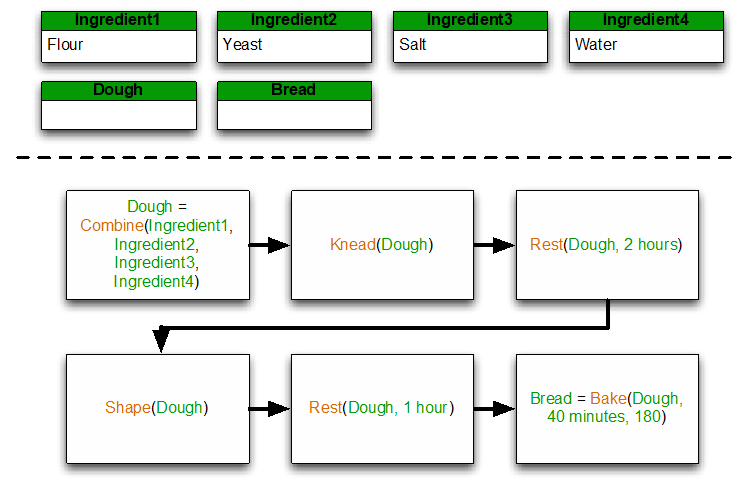

In [2]:
from IPython.display import Image, display

# This renders the file directly without loading it as a PIL object first
display(Image(filename='pictures/programming_recipe_picture1.png'))

## 1. Your first function

Let’s start simple. Suppose we repeatedly need to convert energy from **Gigajoules (GJ)** to **Megawatt-hours (MWh)**.

Since \(1\text{ MWh} = 3.6\text{ GJ}\), we can define a function:

In [3]:
def gj_to_mwh(energy_gj):
    """
    Convert energy from Gigajoules (GJ) to Megawatt-hours (MWh).
    """
    energy_mwh = energy_gj / 3.6
    return energy_mwh


Now we can call this function as often as we like:

In [4]:
print(gj_to_mwh(180))
print(gj_to_mwh(72))

50.0
20.0



✅ **Key idea:** a function saves effort and reduces mistakes when repeating the same calculation.



## 2. Function arguments and return values

Every function can take **inputs** (called *arguments*) and give **outputs** (via the `return` keyword).

Let’s expand our example. Suppose we want to compute **energy intensity** (energy per GDP) for a country.


In [5]:
def energy_intensity(energy_gj, gdp_usd):
    """
    Compute energy intensity: energy per GDP (GJ per USD).
    """
    return energy_gj / gdp_usd

Now we can reuse it easily across many countries:

In [6]:
energy_GJ = {
    "Switzerland": 120,
    "Austria": 150,
    "Germany": 180,
}

gdp_per_capita = {
    "Switzerland": 95000,
    "Austria": 70000,
    "Germany": 80000,
}

for c in energy_GJ:
    ei = energy_intensity(energy_GJ[c], gdp_per_capita[c])
    print(c, "→", round(ei, 4), "GJ per $GDP")

Switzerland → 0.0013 GJ per $GDP
Austria → 0.0021 GJ per $GDP
Germany → 0.0022 GJ per $GDP



This is how you make your code **modular**. Small building blocks that can be combined in larger analyses.

---

## 3. Functions with conditional logic

You can use `if` statements *inside* functions too.

Suppose you want to classify whether a country is “low”, “medium”, or “high” energy intensity:

In [7]:
def classify_intensity(ei):
    """
    Classify a country's energy intensity into categories.
    """
    if ei > 0.0025:
        return "high"
    elif ei > 0.0015:
        return "medium"
    else:
        return "low"


Let’s combine it with our earlier loop:

In [8]:
for c in energy_GJ:
    ei = energy_intensity(energy_GJ[c], gdp_per_capita[c])
    category = classify_intensity(ei)
    print(f"{c} → {category} energy intensity")

Switzerland → low energy intensity
Austria → medium energy intensity
Germany → medium energy intensity


Notice how each function does **one thing correct**. This is the essence of clean code.

---

## 4. Multiple arguments and default values

Sometimes you want to allow flexibility — e.g., assume a different energy-to-GDP conversion factor.

In [9]:
def energy_intensity(energy_gj, gdp_usd, factor=1):
    """
    Compute energy intensity with an optional scaling factor.
    """
    return (energy_gj / gdp_usd) * factor

Now you can call it either normally or with a custom factor:

In [10]:
print(energy_intensity(150, 70000))           # normal
print(energy_intensity(150, 70000, factor=2)) # scaled

0.002142857142857143
0.004285714285714286



Default arguments make your functions adaptable without requiring you to rewrite them.

---

## 5. Why functions matter in ecological economics

Functions are crucial for structuring quantitative models.  
Later in the course you will see that they allow us to:

- Make scenario calculations cleanly
- Compute inequality metrics (e.g., Gini coefficients) in a modular way and correct way
- Define agent behaviors (`def decide_investment()`)

and much more

Think of functions as the **organs** of your code: each performs one vital function, but together they make the whole system work.

In your later models (e.g., when we simulate inequality or compute Gini coefficients),  
functions will handle key computations like income updates, taxation rules, or saving decisions.

---


### 🧩 Exercise

Define a function that computes the **percentage change** between two years of per-capita emissions.

In [11]:
def pct_change(old, new):
    """
    Compute percentage change between two values.
    """
    return ((new - old) / old) * 100

# Example data
emissions_2020 = 5.2
emissions_2024 = 4.7

change = pct_change(emissions_2020, emissions_2024)
print("Change:", round(change, 2), "%")

Change: -9.62 %




:::{dropdown} 💡 *Solution explanation*
- The function takes two arguments: the old and new values.  
- It computes the relative change in percent.  
- Try reversing the order or testing with different values!
:::

---

### Summary

| Concept | Description | Example |
|----------|--------------|----------|
| `def` | defines a function | `def my_function():` |
| Arguments | inputs to the function | `(x, y)` |
| `return` | outputs from the function | `return x + y` |
| Default argument | optional value | `factor=1` |
| Combining functions | modular design | use `energy_intensity()` and `classify_intensity()` together |

---

✅ **Key takeaway:**  
Functions make your code *reusable*, *readable*, and *modular*.  
They are the foundation for complex models — from computing energy intensities to building agent-based economies.

---

### Next steps

Next, we’ll learn about a key concept in computer science and programming - algorithms. 